# EV Charging Load Prediction - Advanced Competition EDA

This notebook is a competition-oriented EDA for the EV charging load forecasting task. It keeps the chapter-based style of `01_eda`, but goes deeper on modeling decisions, calendar effects, leakage, and the real value of external tables.

## Contents
1. Data Loading & Basic Info
2. Time Series Analysis
3. Intraday Structure & Predictability
4. Calendar Effects (Weekend / Holiday / Make-up Workday)
5. Holiday Event Study
6. External Tables: Signal or Just Time Encoding?
7. Leakage Risk Audit
8. EDA 结论与建模建议


In [1]:
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


TRAIN_COLUMNS = [
    "NAME",
    "SENID",
    "TIME",
    "V",
    "AVGV",
    "MAXV",
    "MAXT",
    "MINV",
    "MINT",
    "S",
    "AVGS",
    "MAXS",
    "MINS",
    "SPAN",
]

HOLIDAYS_2024 = {
    "2024-01-01": "NewYear",
    "2024-02-10": "SpringFestival",
    "2024-02-11": "SpringFestival",
    "2024-02-12": "SpringFestival",
    "2024-02-13": "SpringFestival",
    "2024-02-14": "SpringFestival",
    "2024-02-15": "SpringFestival",
    "2024-02-16": "SpringFestival",
    "2024-02-17": "SpringFestival",
    "2024-04-04": "Qingming",
    "2024-04-05": "Qingming",
    "2024-04-06": "Qingming",
    "2024-05-01": "LabourDay",
    "2024-05-02": "LabourDay",
    "2024-05-03": "LabourDay",
    "2024-05-04": "LabourDay",
    "2024-05-05": "LabourDay",
    "2024-06-10": "DragonBoat",
    "2024-09-15": "MidAutumn",
    "2024-09-16": "MidAutumn",
    "2024-09-17": "MidAutumn",
    "2024-10-01": "NationalDay",
    "2024-10-02": "NationalDay",
    "2024-10-03": "NationalDay",
    "2024-10-04": "NationalDay",
    "2024-10-05": "NationalDay",
    "2024-10-06": "NationalDay",
    "2024-10-07": "NationalDay",
}

MAKEUP_WORKDAYS_2024 = {
    "2024-02-04",
    "2024-02-18",
    "2024-04-07",
    "2024-04-28",
    "2024-05-11",
    "2024-09-14",
    "2024-09-29",
    "2024-10-12",
}

DAYTYPE_ORDER = ["weekday", "weekend", "holiday", "makeup_workday"]
DAYTYPE_LABELS = {
    "weekday": "Weekday",
    "weekend": "Weekend",
    "holiday": "Holiday",
    "makeup_workday": "Make-up workday",
}
DAYTYPE_COLORS = {
    "weekday": "#1f4e79",
    "weekend": "#d95f02",
    "holiday": "#7570b3",
    "makeup_workday": "#1b9e77",
}

FIGURE_NAMES = {
    "full_timeseries": "fig_full_timeseries.png",
    "daily_mean_timeline": "fig_daily_mean_timeline.png",
    "daytype_profiles": "fig_daytype_profiles.png",
    "month_slot_heatmap": "fig_month_slot_heatmap.png",
    "peak_slot_distribution": "fig_peak_slot_distribution.png",
    "holiday_family": "fig_holiday_family.png",
    "external_value_check": "fig_external_value_check.png",
    "leakage_correlation": "fig_leakage_correlation.png",
}


def configure_plotting() -> None:
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams["figure.figsize"] = (12, 6)
    plt.rcParams["font.size"] = 12
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["font.sans-serif"] = [
        "Arial Unicode MS",
        "PingFang SC",
        "Hiragino Sans GB",
        "Microsoft YaHei",
        "SimHei",
        "DejaVu Sans",
    ]
    plt.rcParams["axes.unicode_minus"] = False


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "raw").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")


def slot_to_hhmm(slot: int) -> str:
    return f"{slot // 4:02d}:{(slot % 4) * 15:02d}"


def load_train(project_root: Path) -> pd.DataFrame:
    raw_path = project_root / "data" / "raw" / "A榜-充电站充电负荷训练数据.csv"
    train_df = pd.read_csv(raw_path, encoding="gbk", skiprows=1)
    train_df.columns = TRAIN_COLUMNS
    train_df["TIME"] = pd.to_datetime(train_df["TIME"])
    for column in ["V", "AVGV", "MAXV", "MINV", "S", "AVGS", "MAXS", "MINS", "SPAN"]:
        train_df[column] = pd.to_numeric(train_df[column])
    return train_df


def load_external(project_root: Path) -> dict[str, pd.DataFrame]:
    raw_dir = project_root / "data" / "raw"
    pv_df = pd.read_excel(raw_dir / "附件2-光伏典型出力.xlsx")
    pv_df.columns = ["period", "pv_kw"]
    pv_df["slot"] = np.arange(len(pv_df))

    v2g_df = pd.read_csv(raw_dir / "附件1-V2G站向电网售电及从电网购电电价.csv", encoding="gbk")
    ev_price_df = pd.read_csv(raw_dir / "附件3 -EV用户充放电电价.csv", encoding="gbk")
    ev_price_df["hour"] = ev_price_df["时段"].str.extract(r"^(\d+):").astype(int)
    return {"pv": pv_df, "v2g": v2g_df, "ev_price": ev_price_df}


def enrich_train(train_df: pd.DataFrame, external: dict[str, pd.DataFrame]) -> pd.DataFrame:
    holiday_dates = {pd.Timestamp(date_str).date() for date_str in HOLIDAYS_2024}
    makeup_dates = {pd.Timestamp(date_str).date() for date_str in MAKEUP_WORKDAYS_2024}

    df = train_df.copy()
    df["date_ts"] = pd.to_datetime(df["TIME"].dt.date)
    df["date"] = df["date_ts"].dt.date
    df["hour"] = df["TIME"].dt.hour
    df["minute"] = df["TIME"].dt.minute
    df["slot"] = df["hour"] * 4 + df["minute"] // 15
    df["dow"] = df["TIME"].dt.dayofweek
    df["month"] = df["TIME"].dt.month
    df["day"] = df["TIME"].dt.day
    df["is_weekend"] = df["dow"] >= 5
    df["holiday_name"] = df["date"].map(lambda d: HOLIDAYS_2024.get(str(d)))
    df["is_holiday"] = df["date"].isin(holiday_dates)
    df["is_makeup_workday"] = df["date"].isin(makeup_dates)
    df["day_type"] = np.select(
        [df["is_holiday"], df["is_makeup_workday"], df["is_weekend"]],
        ["holiday", "makeup_workday", "weekend"],
        default="weekday",
    )

    pv_map = external["pv"].set_index("slot")["pv_kw"]
    df["pv_kw"] = df["slot"].map(pv_map)
    df["pv_mw"] = df["pv_kw"] / 1000.0

    sell_row = external["v2g"].iloc[0, 1:].astype(float).to_list()
    buy_row = external["v2g"].iloc[1, 1:].astype(float).to_list()
    sell_slot_map: dict[int, float] = {}
    buy_slot_map: dict[int, float] = {}
    for slot in range(96):
        hour = slot // 4
        if hour < 6:
            idx = 0
        elif hour < 10:
            idx = 1
        elif hour < 14:
            idx = 2
        elif hour < 18:
            idx = 3
        else:
            idx = 4
        sell_slot_map[slot] = sell_row[idx]
        buy_slot_map[slot] = buy_row[idx]

    df["v2g_sell_price"] = df["slot"].map(sell_slot_map)
    df["v2g_buy_price"] = df["slot"].map(buy_slot_map)

    charge_map = dict(zip(external["ev_price"]["hour"], external["ev_price"]["充电电价(元/kWh)"]))
    discharge_map = dict(zip(external["ev_price"]["hour"], external["ev_price"]["放电电价(元/kWh)"]))
    df["ev_charge_price"] = df["hour"].map(charge_map)
    df["ev_discharge_price"] = df["hour"].map(discharge_map)
    return df


def build_daily(train_df: pd.DataFrame) -> pd.DataFrame:
    daily_df = train_df.groupby("date_ts").agg(
        mean_v=("V", "mean"),
        max_v=("V", "max"),
        min_v=("V", "min"),
        total_v=("V", "sum"),
        month=("month", "first"),
        dow=("dow", "first"),
        day_type=("day_type", "first"),
        holiday_name=("holiday_name", "first"),
        is_holiday=("is_holiday", "first"),
        is_makeup_workday=("is_makeup_workday", "first"),
    )
    daily_df["peak_slot"] = train_df.loc[train_df.groupby("date_ts")["V"].idxmax()].set_index("date_ts")["slot"]
    daily_df["valley_slot"] = train_df.loc[train_df.groupby("date_ts")["V"].idxmin()].set_index("date_ts")["slot"]
    return daily_df


def build_context(project_root: Path | None = None) -> dict[str, object]:
    root = find_project_root(project_root)
    train_df = enrich_train(load_train(root), load_external(root))
    daily_df = build_daily(train_df)

    slot_profile = train_df.groupby(["day_type", "slot"])["V"].mean().unstack("day_type")
    peak_per_day = train_df.loc[train_df.groupby("date_ts")["V"].idxmax(), ["date_ts", "slot", "day_type"]].copy()
    day_type_stats = daily_df.groupby("day_type")["mean_v"].agg(["count", "mean", "std"]).reindex(DAYTYPE_ORDER)

    holiday_family_stats = (
        daily_df[daily_df["holiday_name"].notna()]
        .groupby("holiday_name")["mean_v"]
        .agg(["count", "mean", "std"])
        .sort_values("mean", ascending=False)
    )

    slot_mean = train_df.groupby("slot")["V"].mean()
    train_df["slot_mean"] = train_df.groupby("slot")["V"].transform("mean")
    train_df["slot_residual"] = train_df["V"] - train_df["slot_mean"]

    external_eval_rows = []
    for column in ["pv_mw", "v2g_buy_price", "v2g_sell_price", "ev_charge_price", "ev_discharge_price"]:
        raw_corr = float(np.corrcoef(train_df["V"], train_df[column])[0, 1])
        residual_corr = float(np.corrcoef(train_df["slot_residual"], train_df[column])[0, 1])
        external_eval_rows.append(
            {"feature": column, "raw_corr": raw_corr, "residual_corr": residual_corr}
        )
    external_eval_df = pd.DataFrame(external_eval_rows)

    slot_features = pd.get_dummies(train_df["slot"].astype(str), prefix="slot")
    slot_month_dow = pd.concat(
        [
            slot_features,
            pd.get_dummies(train_df["month"].astype(str), prefix="month", drop_first=True),
            pd.get_dummies(train_df["dow"].astype(str), prefix="dow", drop_first=True),
        ],
        axis=1,
    )
    plus_det = pd.concat(
        [
            slot_month_dow,
            train_df[
                [
                    "pv_mw",
                    "v2g_buy_price",
                    "v2g_sell_price",
                    "ev_charge_price",
                    "ev_discharge_price",
                ]
            ].reset_index(drop=True),
        ],
        axis=1,
    )
    slot_month_dow_model = LinearRegression().fit(slot_month_dow, train_df["V"])
    plus_det_model = LinearRegression().fit(plus_det, train_df["V"])
    baseline_r2 = float(r2_score(train_df["V"], slot_month_dow_model.predict(slot_month_dow)))
    plus_det_r2 = float(r2_score(train_df["V"], plus_det_model.predict(plus_det)))

    leakage_corr = (
        train_df[["V", "S", "AVGV", "MAXV", "MINV", "AVGS", "MAXS", "MINS", "SPAN"]]
        .corr()["V"]
        .drop("V")
        .sort_values(ascending=False)
    )
    avgv_diff = (train_df["AVGV"] - train_df.groupby("date_ts")["V"].transform("mean")).abs()

    regular_weekday = daily_df.loc[daily_df["day_type"] == "weekday", "mean_v"]
    regular_weekend = daily_df.loc[daily_df["day_type"] == "weekend", "mean_v"]
    holiday_mean = daily_df.loc[daily_df["day_type"] == "holiday", "mean_v"]
    makeup_mean = daily_df.loc[daily_df["day_type"] == "makeup_workday", "mean_v"]

    series = train_df["V"].to_numpy()
    lag_corr = {
        "lag_1": float(np.corrcoef(series[:-1], series[1:])[0, 1]),
        "lag_96": float(np.corrcoef(series[:-96], series[96:])[0, 1]),
        "lag_672": float(np.corrcoef(series[:-672], series[672:])[0, 1]),
    }

    weekend_minus_weekday = (slot_profile["weekend"] - slot_profile["weekday"]).sort_values(ascending=False)
    holiday_minus_weekday = (slot_profile["holiday"] - slot_profile["weekday"]).sort_values(ascending=False)
    peak_slot_counts = {
        day_type: peak_per_day.loc[peak_per_day["day_type"] == day_type, "slot"].value_counts().sort_values(ascending=False)
        for day_type in DAYTYPE_ORDER
    }

    recent_28d_start = train_df["TIME"].max() - pd.Timedelta(days=28) + pd.Timedelta(minutes=15)
    future_days = pd.date_range("2024-11-01", "2024-12-31", freq="D")
    future_holidays = {day for day in future_days.date if str(day) in HOLIDAYS_2024}

    summary = {
        "rows": int(train_df.shape[0]),
        "days": int(daily_df.shape[0]),
        "missing_timestamps": int(
            len(pd.date_range(train_df["TIME"].min(), train_df["TIME"].max(), freq="15min").difference(train_df["TIME"]))
        ),
        "peak_slot": int(slot_mean.idxmax()),
        "peak_mean": float(slot_mean.max()),
        "valley_slot": int(slot_mean.idxmin()),
        "valley_mean": float(slot_mean.min()),
        "evening_peak_mean": float(slot_mean.loc[72:79].mean()),
        "full_mean": float(train_df["V"].mean()),
        "recent_28d_mean": float(train_df.loc[train_df["TIME"] >= recent_28d_start, "V"].mean()),
        "july_aug_mean": float(train_df.loc[train_df["month"].isin([7, 8]), "V"].mean()),
        "sep_oct_mean": float(train_df.loc[train_df["month"].isin([9, 10]), "V"].mean()),
        "weekend_vs_weekday_pct": float((regular_weekend.mean() - regular_weekday.mean()) / regular_weekday.mean() * 100),
        "holiday_vs_weekday_pct": float((holiday_mean.mean() - regular_weekday.mean()) / regular_weekday.mean() * 100),
        "makeup_vs_weekday_pct": float((makeup_mean.mean() - regular_weekday.mean()) / regular_weekday.mean() * 100),
        "baseline_r2": baseline_r2,
        "plus_det_r2": plus_det_r2,
        "future_holiday_count": int(len(future_holidays)),
        "avgv_mean_abs_diff": float(avgv_diff.mean()),
        "train_start": train_df["TIME"].min().strftime("%Y-%m-%d %H:%M"),
        "train_end": train_df["TIME"].max().strftime("%Y-%m-%d %H:%M"),
        **lag_corr,
    }

    return {
        "project_root": root,
        "train_df": train_df,
        "daily_df": daily_df,
        "slot_profile": slot_profile,
        "peak_per_day": peak_per_day,
        "day_type_stats": day_type_stats,
        "holiday_family_stats": holiday_family_stats,
        "external_eval_df": external_eval_df,
        "leakage_corr": leakage_corr,
        "weekend_minus_weekday": weekend_minus_weekday,
        "holiday_minus_weekday": holiday_minus_weekday,
        "peak_slot_counts": peak_slot_counts,
        "summary": summary,
    }


def save_figures(context: dict[str, object], output_dir: Path) -> dict[str, Path]:
    configure_plotting()
    output_dir.mkdir(parents=True, exist_ok=True)

    train_df: pd.DataFrame = context["train_df"]  # type: ignore[assignment]
    daily_df: pd.DataFrame = context["daily_df"]  # type: ignore[assignment]
    slot_profile: pd.DataFrame = context["slot_profile"]  # type: ignore[assignment]
    peak_per_day: pd.DataFrame = context["peak_per_day"]  # type: ignore[assignment]
    holiday_family_stats: pd.DataFrame = context["holiday_family_stats"]  # type: ignore[assignment]
    external_eval_df: pd.DataFrame = context["external_eval_df"]  # type: ignore[assignment]
    leakage_corr: pd.Series = context["leakage_corr"]  # type: ignore[assignment]

    figure_paths = {key: output_dir / filename for key, filename in FIGURE_NAMES.items()}

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(train_df["TIME"], train_df["V"], linewidth=0.5, alpha=0.9, color="#1f4e79")
    ax.set_xlabel("Time")
    ax.set_ylabel("Charging Power (MW)")
    ax.set_title("Full Training Period Charging Load (2024/1/1 - 2024/10/31)")
    month_ticks = pd.date_range("2024-01-01", "2024-11-01", freq="MS")
    ax.set_xticks(month_ticks)
    ax.set_xticklabels([tick.strftime("%Y-%m") for tick in month_ticks], rotation=45)
    fig.tight_layout()
    fig.savefig(figure_paths["full_timeseries"], dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(daily_df.index, daily_df["mean_v"], color="#37474f", linewidth=1.6)
    for day_type in ["weekend", "holiday", "makeup_workday"]:
        subset = daily_df[daily_df["day_type"] == day_type]
        ax.scatter(
            subset.index,
            subset["mean_v"],
            s=18,
            label=DAYTYPE_LABELS[day_type],
            color=DAYTYPE_COLORS[day_type],
            alpha=0.85,
        )
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily Mean Load (MW)")
    ax.set_title("Daily Mean Load Timeline with Special Day Labels")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(figure_paths["daily_mean_timeline"], dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, ax1 = plt.subplots(figsize=(14, 6))
    for day_type in DAYTYPE_ORDER:
        if day_type in slot_profile.columns:
            ax1.plot(
                slot_profile.index,
                slot_profile[day_type],
                linewidth=2.2,
                label=DAYTYPE_LABELS[day_type],
                color=DAYTYPE_COLORS[day_type],
            )
    ax1.set_xlabel("15-minute Slot")
    ax1.set_ylabel("Charging Power (MW)")
    ax1.set_title("Average Load Profile by Day Type")
    ax1.set_xticks(np.arange(0, 96, 8))
    ax1.set_xticklabels([slot_to_hhmm(int(slot)) for slot in np.arange(0, 96, 8)], rotation=45)
    ax2 = ax1.twinx()
    pv_profile = train_df.groupby("slot")["pv_mw"].first()
    ax2.fill_between(slot_profile.index, pv_profile, color="#f1c232", alpha=0.18, label="Typical PV output")
    ax2.set_ylabel("PV Output (MW)")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    fig.tight_layout()
    fig.savefig(figure_paths["daytype_profiles"], dpi=150, bbox_inches="tight")
    plt.close(fig)

    heatmap = train_df.groupby(["month", "slot"])["V"].mean().unstack("slot")
    fig, ax = plt.subplots(figsize=(14, 6))
    image = ax.imshow(heatmap.values, aspect="auto", cmap="YlOrRd")
    ax.set_xlabel("15-minute Slot")
    ax.set_ylabel("Month")
    ax.set_title("Month x 15-minute Slot Mean Load")
    ax.set_yticks(np.arange(len(heatmap.index)))
    ax.set_yticklabels([f"{month:02d}" for month in heatmap.index])
    ax.set_xticks(np.arange(0, 96, 8))
    ax.set_xticklabels([slot_to_hhmm(int(slot)) for slot in np.arange(0, 96, 8)], rotation=45, ha="right")
    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label("MW")
    fig.tight_layout()
    fig.savefig(figure_paths["month_slot_heatmap"], dpi=150, bbox_inches="tight")
    plt.close(fig)

    top_slots = sorted(peak_per_day["slot"].value_counts().head(8).index.tolist())
    peak_table = (
        peak_per_day[peak_per_day["slot"].isin(top_slots)]
        .groupby(["slot", "day_type"])
        .size()
        .unstack("day_type")
        .reindex(top_slots)
        .fillna(0)
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(peak_table.index))
    width = 0.2
    for idx, day_type in enumerate(DAYTYPE_ORDER):
        if day_type in peak_table.columns:
            ax.bar(
                x + (idx - 1.5) * width,
                peak_table[day_type].values,
                width,
                label=DAYTYPE_LABELS[day_type],
                color=DAYTYPE_COLORS[day_type],
            )
    ax.set_xlabel("Peak Slot")
    ax.set_ylabel("Number of Days")
    ax.set_title("Daily Peak-Time Distribution by Day Type")
    ax.set_xticks(x)
    ax.set_xticklabels([slot_to_hhmm(int(slot)) for slot in peak_table.index])
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(figure_paths["peak_slot_distribution"], dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 5))
    holiday_plot = holiday_family_stats.reset_index()
    ax.bar(holiday_plot["holiday_name"], holiday_plot["mean"], color="#4e79a7", alpha=0.85)
    ax.errorbar(
        holiday_plot["holiday_name"],
        holiday_plot["mean"],
        yerr=holiday_plot["std"].fillna(0.0),
        fmt="none",
        ecolor="#1f1f1f",
        capsize=4,
    )
    ax.set_xlabel("Holiday Family")
    ax.set_ylabel("Daily Mean Load (MW)")
    ax.set_title("Holiday Family Load Levels")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    fig.savefig(figure_paths["holiday_family"], dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(external_eval_df))
    width = 0.35
    axes[0].bar(x - width / 2, external_eval_df["raw_corr"], width, label="Raw corr", color="#4e79a7")
    axes[0].bar(
        x + width / 2,
        external_eval_df["residual_corr"],
        width,
        label="Corr after removing slot mean",
        color="#f28e2b",
    )
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(external_eval_df["feature"], rotation=25, ha="right")
    axes[0].set_title("External Features: Raw vs Residual Correlation")
    axes[0].legend()

    axes[1].bar(
        ["slot+month+dow", "plus deterministic externals"],
        [
            context["summary"]["baseline_r2"],  # type: ignore[index]
            context["summary"]["plus_det_r2"],  # type: ignore[index]
        ],
        color=["#59a14f", "#e15759"],
        alpha=0.85,
    )
    axes[1].set_ylim(
        min(context["summary"]["baseline_r2"], context["summary"]["plus_det_r2"]) - 0.01,  # type: ignore[index]
        max(context["summary"]["baseline_r2"], context["summary"]["plus_det_r2"]) + 0.01,  # type: ignore[index]
    )
    axes[1].set_ylabel("R²")
    axes[1].set_title("Do External Tables Add Information Beyond Time Slot?")
    fig.tight_layout()
    fig.savefig(figure_paths["external_value_check"], dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(leakage_corr.index, leakage_corr.values, color="#76b7b2", alpha=0.9)
    ax.axhline(0.0, color="#444444", linewidth=1)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Correlation with V")
    ax.set_title("Target Correlation of Same-Day Summary Fields")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    fig.savefig(figure_paths["leakage_correlation"], dpi=150, bbox_inches="tight")
    plt.close(fig)

    return figure_paths

configure_plotting()


---
## 1. Data Loading & Basic Info


In [2]:
PROJECT_ROOT = find_project_root(Path.cwd())
context = build_context(PROJECT_ROOT)

train_df = context['train_df']
daily_df = context['daily_df']
slot_profile = context['slot_profile']
day_type_stats = context['day_type_stats']
holiday_family_stats = context['holiday_family_stats']
external_eval_df = context['external_eval_df']
leakage_corr = context['leakage_corr']
peak_slot_counts = context['peak_slot_counts']
summary = context['summary']

print(f'Project root: {PROJECT_ROOT}')
print(f"Train rows: {summary['rows']:,}")
print(f"Train days: {summary['days']}")
print(f"Train range: {summary['train_start']} -> {summary['train_end']}")
print(f"Missing timestamps: {summary['missing_timestamps']}")
print()
display(train_df.head())


Project root: /Users/z/基于多源数据融合的电动汽车充电协同优化挑战
Train rows: 29,280
Train days: 305
Train range: 2024-01-01 00:00 -> 2024-10-31 23:45
Missing timestamps: 0



,NAME,SENID,TIME,V,AVGV,MAXV,MAXT,MINV,MINT,S,...,is_makeup_workday,day_type,pv_kw,pv_mw,v2g_sell_price,v2g_buy_price,ev_charge_price,ev_discharge_price,slot_mean,slot_residual
0,电动汽车充电站,1001-1012,2024-01-01 00:00:00,6.93,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.241,...,False,holiday,0.0,0.0,0.2,0.3,0.48,0.48,6.331180,0.598820
1,电动汽车充电站,1001-1012,2024-01-01 00:15:00,7.48,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.251,...,False,holiday,0.0,0.0,0.2,0.3,0.48,0.48,6.838033,0.641967
2,电动汽车充电站,1001-1012,2024-01-01 00:30:00,8.22,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.244,...,False,holiday,0.0,0.0,0.2,0.3,0.48,0.48,7.341770,0.878230
3,电动汽车充电站,1001-1012,2024-01-01 00:45:00,8.90,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.244,...,False,holiday,0.0,0.0,0.2,0.3,0.48,0.48,7.800459,1.099541
4,电动汽车充电站,1001-1012,2024-01-01 01:00:00,9.05,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.253,...,False,holiday,0.0,0.0,0.2,0.3,0.54,0.54,8.159049,0.890951


In [3]:
raw_preview = pd.read_csv(
    PROJECT_ROOT / 'data' / 'raw' / 'A榜-充电站充电负荷训练数据.csv',
    encoding='gbk',
    header=None,
    nrows=4
)

interval_counts = train_df['TIME'].diff().dropna().value_counts().head()
quality_table = pd.DataFrame({
    'metric': ['rows', 'days', 'missing_timestamps', 'duplicate_timestamps', 'sampling_interval'],
    'value': [
        len(train_df),
        train_df['date_ts'].nunique(),
        summary['missing_timestamps'],
        int(train_df['TIME'].duplicated().sum()),
        str(interval_counts.index[0])
    ]
})

print('=== Raw CSV preview (notice the first mapping row) ===')
display(raw_preview)
print('=== Data quality audit ===')
display(quality_table)


=== Raw CSV preview (notice the first mapping row) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,名称,ID,日期,充电功率/MW,当日平均充电功率/MW,当日最大充电功率/MW,当日 MAXV 对应时间,当日 V 最小值/MW,当日 MINV 对应时间,充电时长/h,当日所有 S 的均值/h,当日 S 的最大值/h,当日 S 的最小值/h,当日最大充电时长跨度/h
1,NAME,SENID,TIME,V,AVGV,MAXV,MAXT,MINV,MINT,S,AVGS,MAXS,MINS,SPAN
2,电动汽车充电站,1001-1012,2024/1/1 0:00,6.93,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.241,0.24,0.26,0.223,0.037
3,电动汽车充电站,1001-1012,2024/1/1 0:15,7.48,5.17,9.61,2024/1/1 1:30,1.76,2024/1/1 5:45,0.251,0.24,0.26,0.223,0.037


=== Data quality audit ===


,metric,value
0,rows,29280
1,days,305
2,missing_timestamps,0
3,duplicate_timestamps,0
4,sampling_interval,0 days 00:15:00


数据质量并不是这道题的难点，真正的难点在于**行为模式切换**。

- 原始 CSV 第一行是中文字段映射，必须 `skiprows=1`，否则会把脏头当成样本。
- 有效训练样本是 **29,280 条 = 305 天 x 96 个 15 分钟点**。
- 时间序列完整无缺失，这意味着我们可以放心做 lag / rolling / template 特征，而不用先补点。


---
## 2. Time Series Analysis


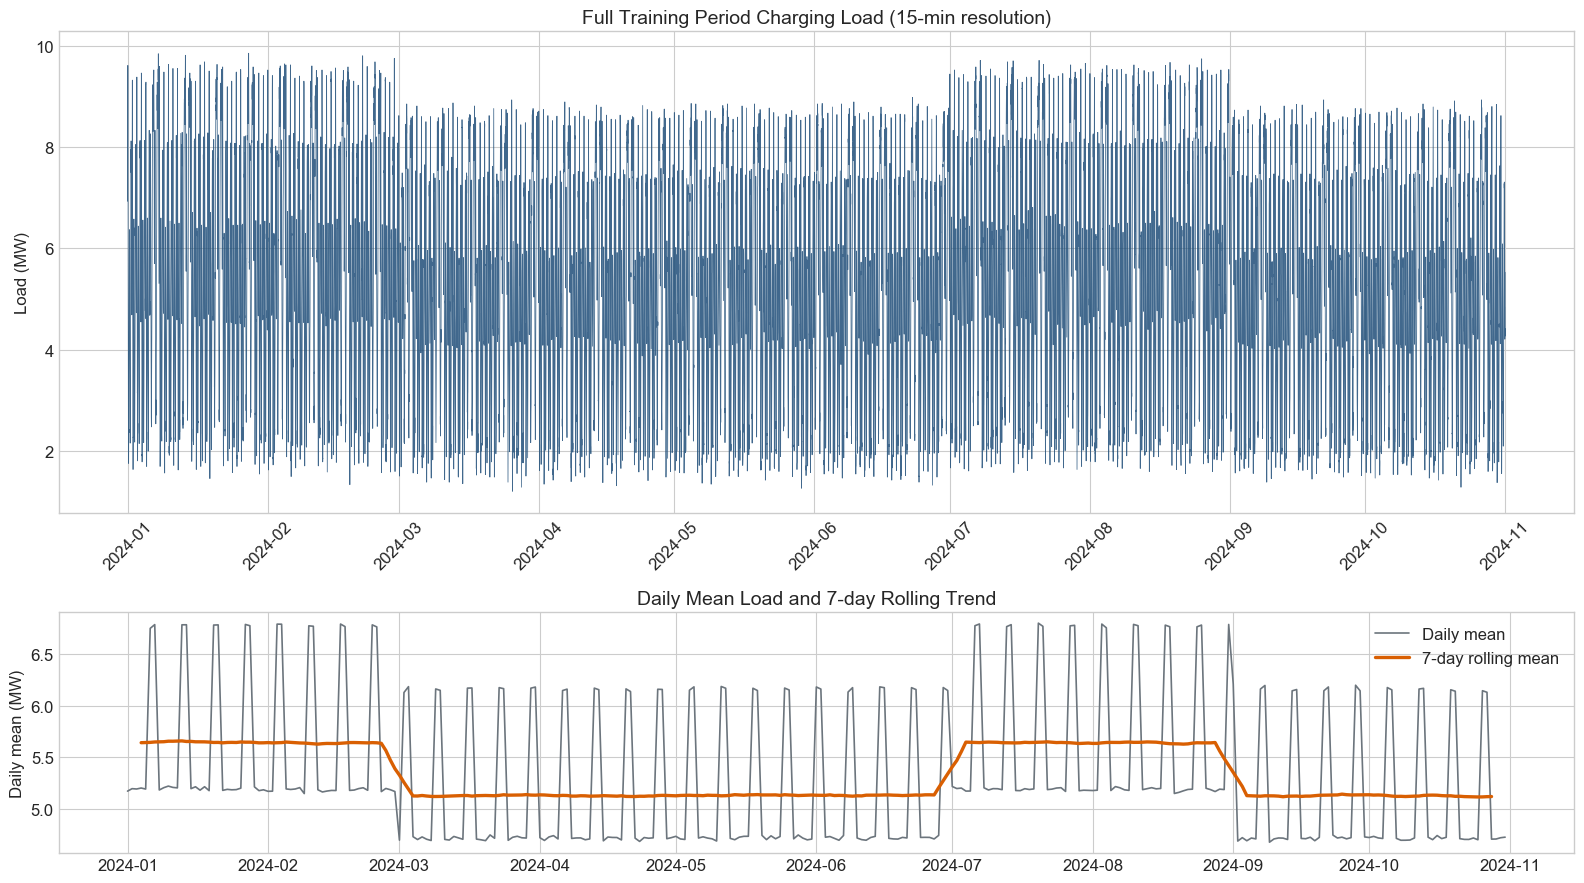

In [4]:
daily_rolling = daily_df['mean_v'].rolling(7, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(train_df['TIME'], train_df['V'], color='#1f4e79', linewidth=0.55, alpha=0.85)
axes[0].set_title('Full Training Period Charging Load (15-min resolution)')
axes[0].set_ylabel('Load (MW)')
month_ticks = pd.date_range('2024-01-01', '2024-11-01', freq='MS')
axes[0].set_xticks(month_ticks)
axes[0].set_xticklabels([tick.strftime('%Y-%m') for tick in month_ticks], rotation=45)

axes[1].plot(daily_df.index, daily_df['mean_v'], color='#6c757d', linewidth=1.2, label='Daily mean')
axes[1].plot(daily_df.index, daily_rolling, color='#d95f02', linewidth=2.4, label='7-day rolling mean')
axes[1].set_title('Daily Mean Load and 7-day Rolling Trend')
axes[1].set_ylabel('Daily mean (MW)')
axes[1].legend()

plt.tight_layout()
plt.show()


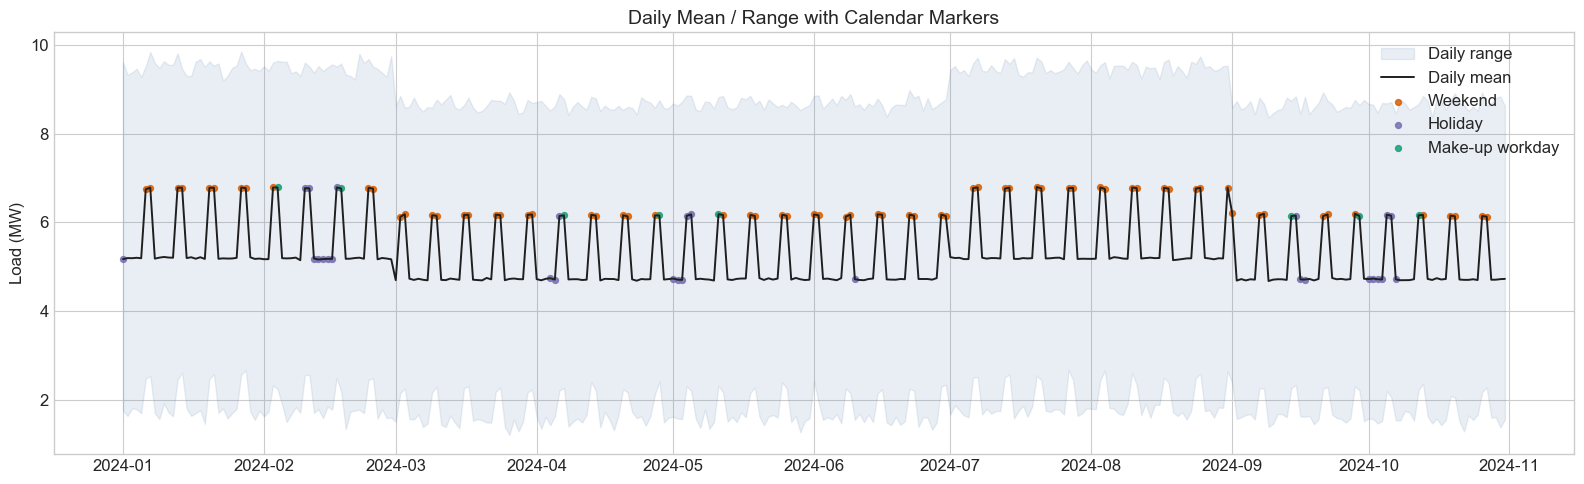

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(daily_df.index, daily_df['min_v'], daily_df['max_v'], color='#4e79a7', alpha=0.12, label='Daily range')
ax.plot(daily_df.index, daily_df['mean_v'], color='#1f1f1f', linewidth=1.4, label='Daily mean')
for day_type, color in [('weekend', '#d95f02'), ('holiday', '#7570b3'), ('makeup_workday', '#1b9e77')]:
    subset = daily_df[daily_df['day_type'] == day_type]
    ax.scatter(subset.index, subset['mean_v'], s=18, color=color, alpha=0.85, label=DAYTYPE_LABELS[day_type])
ax.set_title('Daily Mean / Range with Calendar Markers')
ax.set_ylabel('Load (MW)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


从宏观时间线看，负荷并不是单纯平稳过程。

- 全样本均值是 **5.328 MW**，但近 28 天均值只有 **5.124 MW**。
- 7-8 月均值 **5.623 MW**，9-10 月均值回落到 **5.117 MW**。
- 这直接指向一个比赛层面的结论：**预测 11-12 月时，近期样本应该比年初样本权重更高**。


---
## 3. Intraday Structure & Predictability


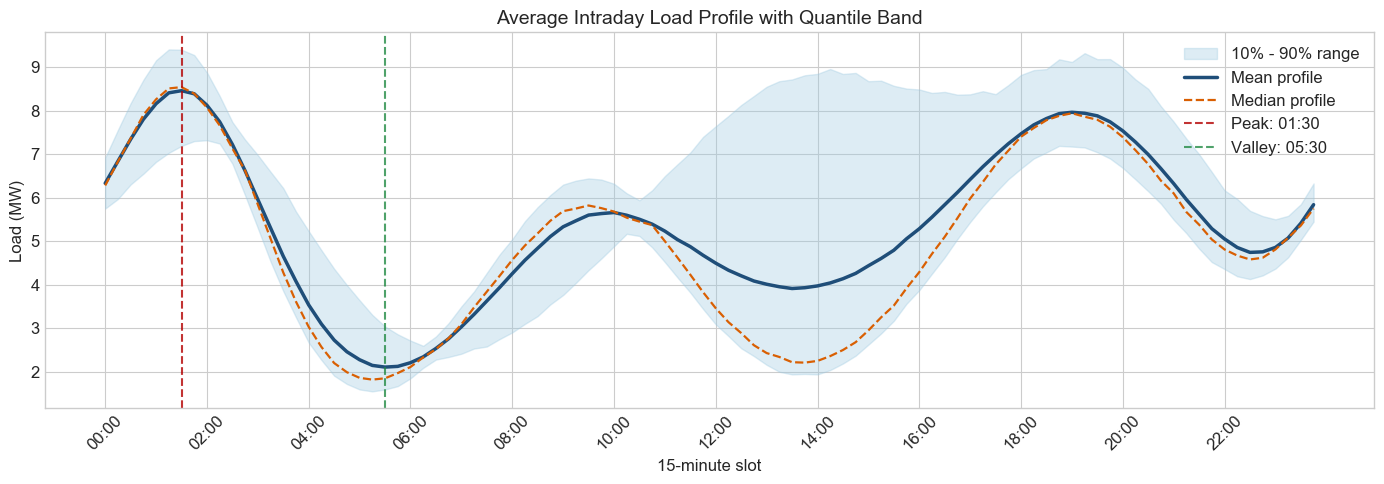

In [6]:
slot_stats = train_df.groupby('slot')['V'].agg(
    mean='mean',
    median='median',
    q10=lambda x: x.quantile(0.10),
    q90=lambda x: x.quantile(0.90),
    std='std'
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(slot_stats.index, slot_stats['q10'], slot_stats['q90'], color='#9ecae1', alpha=0.35, label='10% - 90% range')
ax.plot(slot_stats.index, slot_stats['mean'], color='#1f4e79', linewidth=2.5, label='Mean profile')
ax.plot(slot_stats.index, slot_stats['median'], color='#d95f02', linewidth=1.6, linestyle='--', label='Median profile')
ax.axvline(summary['peak_slot'], color='#b30000', linestyle='--', alpha=0.8, label=f"Peak: {slot_to_hhmm(summary['peak_slot'])}")
ax.axvline(summary['valley_slot'], color='#238b45', linestyle='--', alpha=0.8, label=f"Valley: {slot_to_hhmm(summary['valley_slot'])}")
ax.set_xticks(np.arange(0, 96, 8))
ax.set_xticklabels([slot_to_hhmm(int(slot)) for slot in np.arange(0, 96, 8)], rotation=45)
ax.set_title('Average Intraday Load Profile with Quantile Band')
ax.set_xlabel('15-minute slot')
ax.set_ylabel('Load (MW)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


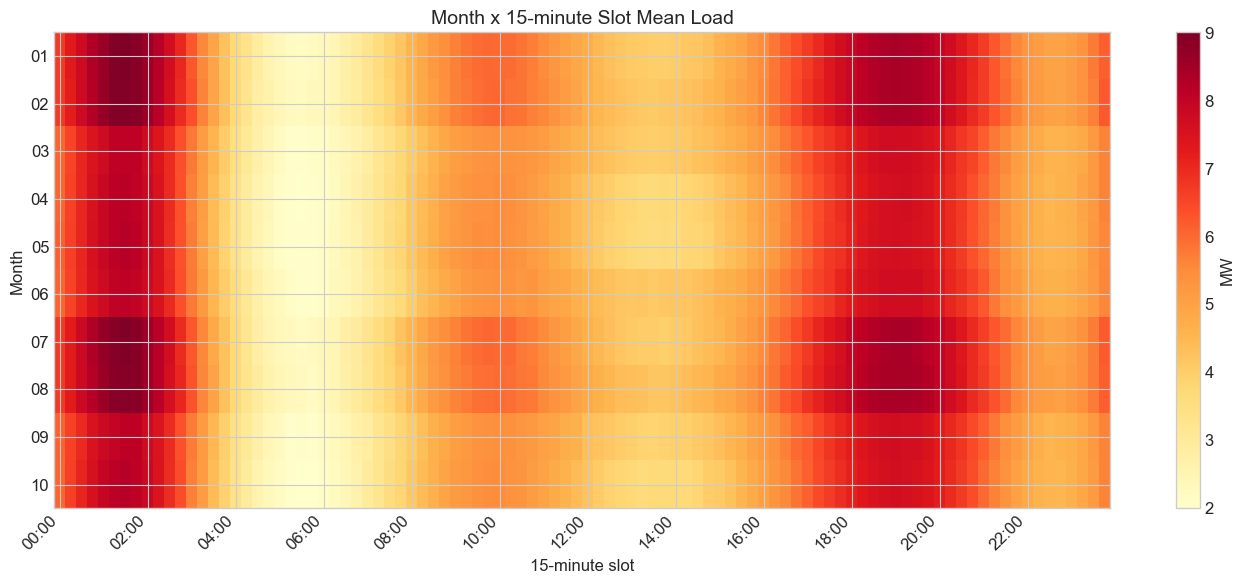

In [7]:
month_slot = train_df.groupby(['month', 'slot'])['V'].mean().unstack('slot')

fig, ax = plt.subplots(figsize=(14, 6))
if 'HAS_SEABORN' in globals() and HAS_SEABORN:
    sns.heatmap(month_slot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'MW'})
else:
    img = ax.imshow(month_slot.values, aspect='auto', cmap='YlOrRd')
    cbar = fig.colorbar(img, ax=ax)
    cbar.set_label('MW')
    ax.set_yticks(np.arange(len(month_slot.index)))
    ax.set_yticklabels([f'{m:02d}' for m in month_slot.index])
ax.set_title('Month x 15-minute Slot Mean Load')
ax.set_xlabel('15-minute slot')
ax.set_ylabel('Month')
ax.set_xticks(np.arange(0, 96, 8))
ax.set_xticklabels([slot_to_hhmm(int(slot)) for slot in np.arange(0, 96, 8)], rotation=45, ha='right')
plt.tight_layout()
plt.show()


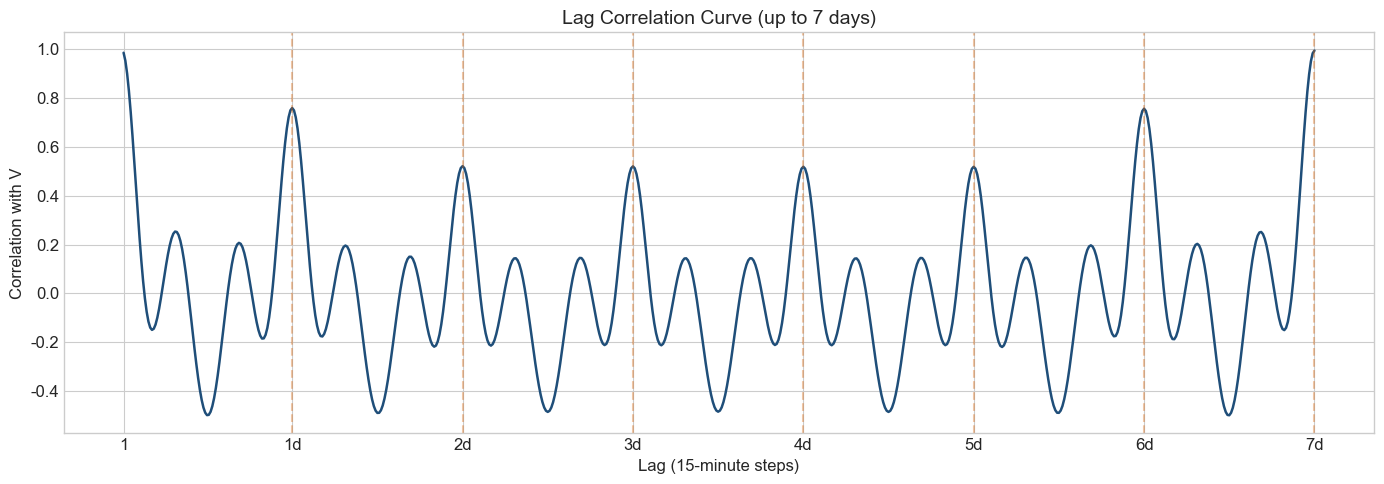

lag_1   = 0.9839
lag_96  = 0.7580
lag_672 = 0.9928


In [8]:
lags = np.arange(1, 96 * 7 + 1)
series = train_df['V'].to_numpy()
lag_corrs = np.array([np.corrcoef(series[:-lag], series[lag:])[0, 1] for lag in lags])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lags, lag_corrs, color='#1f4e79', linewidth=1.8)
for day in range(1, 8):
    ax.axvline(96 * day, color='#d95f02', linestyle='--', alpha=0.35)
ax.set_title('Lag Correlation Curve (up to 7 days)')
ax.set_xlabel('Lag (15-minute steps)')
ax.set_ylabel('Correlation with V')
ax.set_xticks([1, 96, 192, 288, 384, 480, 576, 672])
ax.set_xticklabels(['1', '1d', '2d', '3d', '4d', '5d', '6d', '7d'])
plt.tight_layout()
plt.show()

print(f"lag_1   = {summary['lag_1']:.4f}")
print(f"lag_96  = {summary['lag_96']:.4f}")
print(f"lag_672 = {summary['lag_672']:.4f}")


这部分最重要的不是“晚上有峰”，而是峰值位置和重复性。

- 全样本平均主峰出现在 **01:30**，均值 **8.458 MW**。
- 全样本平均低谷在 **05:30**，均值 **2.107 MW**。
- `18:00-19:45` 晚高峰窗口均值仍有 **7.802 MW**，说明站点是明显双峰结构。
- `lag_96 = 0.7580`、`lag_672 = 0.9928`，说明同日同槽位、同星期同槽位的模板非常强。


---
## 4. Calendar Effects (Weekend / Holiday / Make-up Workday)


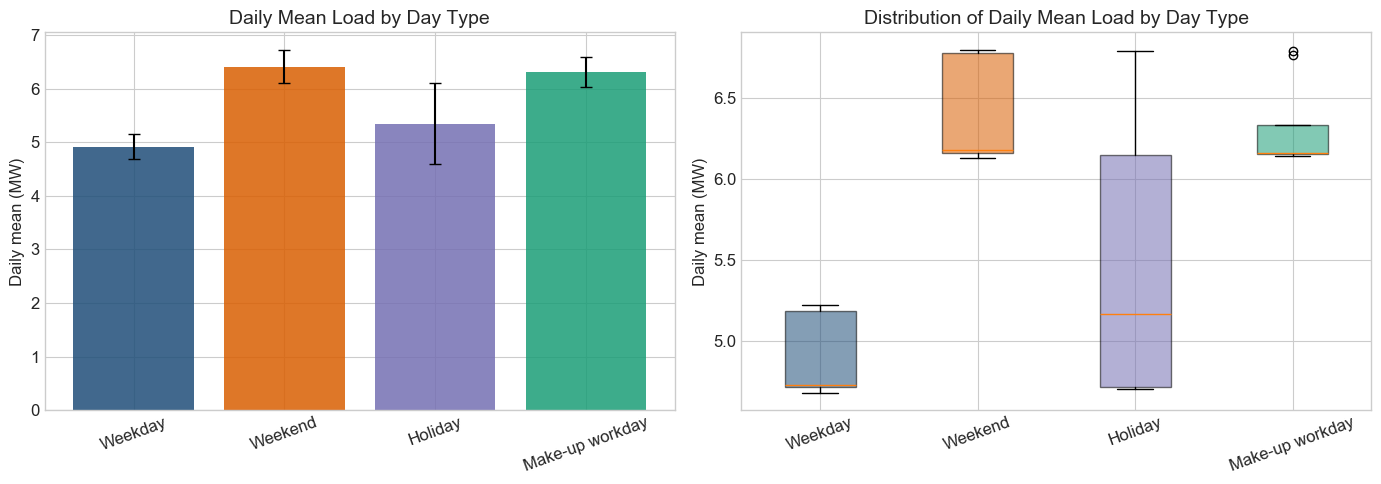

,count,mean,std
day_type,,,
weekday,200,4.912,0.234
weekend,69,6.411,0.304
holiday,28,5.346,0.755
makeup_workday,8,6.312,0.286


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_stats = day_type_stats.reindex(DAYTYPE_ORDER)
axes[0].bar(plot_stats.index, plot_stats['mean'], yerr=plot_stats['std'], color=['#1f4e79', '#d95f02', '#7570b3', '#1b9e77'], alpha=0.85, capsize=4)
axes[0].set_title('Daily Mean Load by Day Type')
axes[0].set_ylabel('Daily mean (MW)')
axes[0].set_xticklabels([DAYTYPE_LABELS[idx] for idx in plot_stats.index], rotation=20)

box_data = [daily_df.loc[daily_df['day_type'] == day_type, 'mean_v'].values for day_type in DAYTYPE_ORDER]
box = axes[1].boxplot(box_data, patch_artist=True, labels=[DAYTYPE_LABELS[dt] for dt in DAYTYPE_ORDER])
for patch, color in zip(box['boxes'], ['#1f4e79', '#d95f02', '#7570b3', '#1b9e77']):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
axes[1].set_title('Distribution of Daily Mean Load by Day Type')
axes[1].set_ylabel('Daily mean (MW)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

display(day_type_stats.round(3))


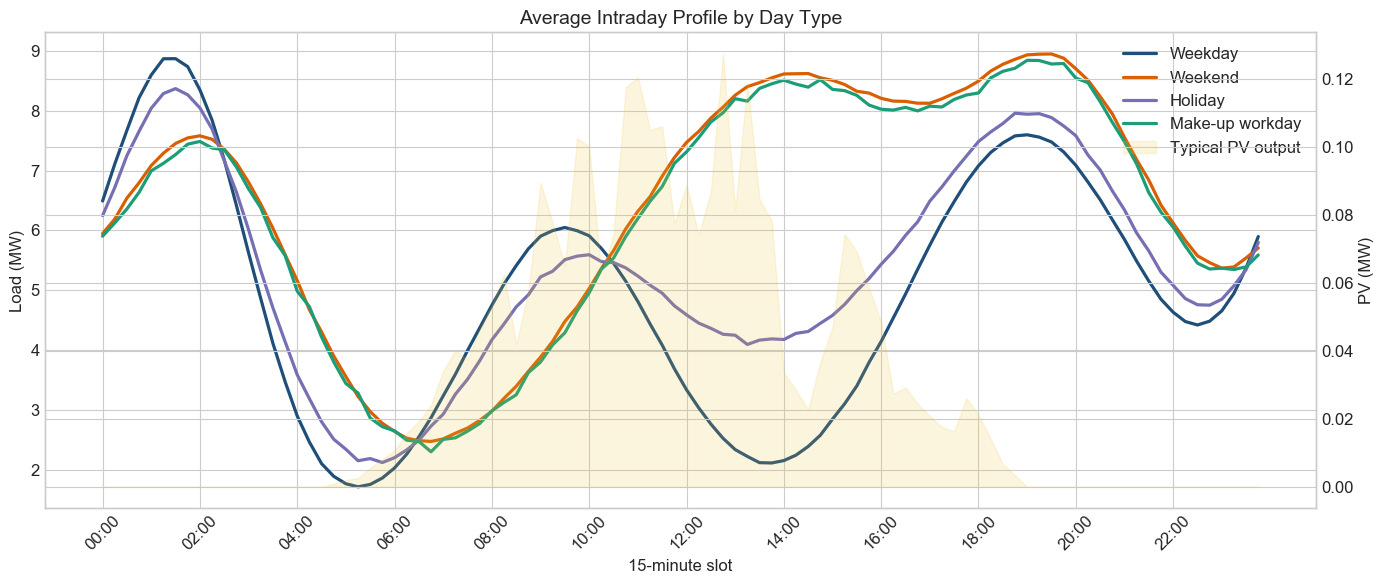

In [10]:
fig, ax1 = plt.subplots(figsize=(14, 6))
for day_type in DAYTYPE_ORDER:
    if day_type in slot_profile.columns:
        ax1.plot(slot_profile.index, slot_profile[day_type], linewidth=2.3, label=DAYTYPE_LABELS[day_type], color=DAYTYPE_COLORS[day_type])
ax1.set_xticks(np.arange(0, 96, 8))
ax1.set_xticklabels([slot_to_hhmm(int(slot)) for slot in np.arange(0, 96, 8)], rotation=45)
ax1.set_xlabel('15-minute slot')
ax1.set_ylabel('Load (MW)')
ax1.set_title('Average Intraday Profile by Day Type')

ax2 = ax1.twinx()
pv_profile = train_df.groupby('slot')['pv_mw'].first()
ax2.fill_between(slot_profile.index, pv_profile, color='#f1c232', alpha=0.16, label='Typical PV output')
ax2.set_ylabel('PV (MW)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()


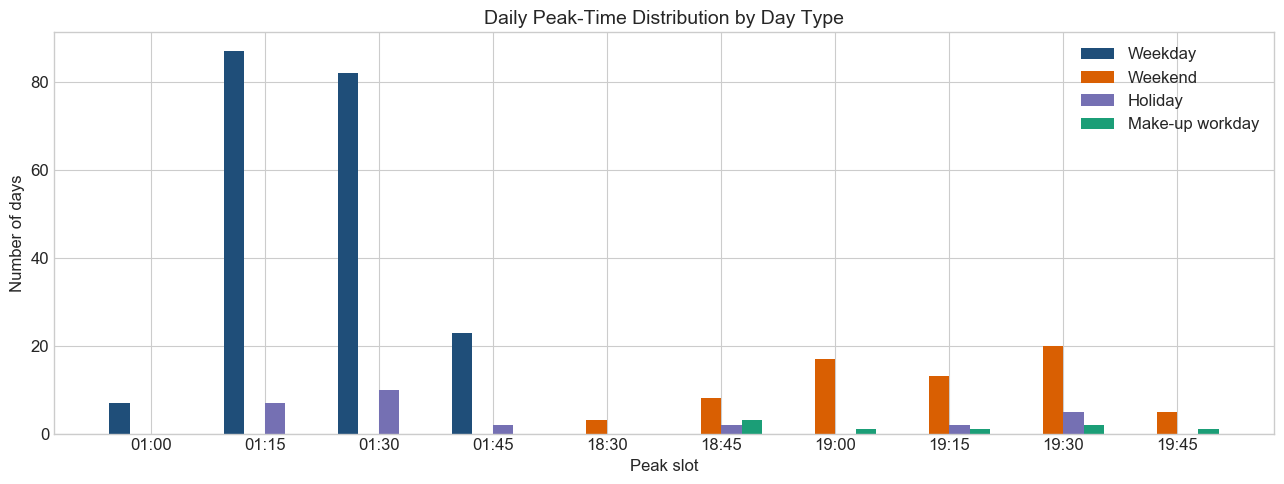

Weekday -> 01:15: 87 days, 01:30: 82 days, 01:45: 23 days, 01:00: 7 days
Weekend -> 19:30: 20 days, 19:00: 17 days, 19:15: 13 days, 18:45: 8 days
Holiday -> 01:30: 10 days, 01:15: 7 days, 19:30: 5 days, 19:15: 2 days
Make-up workday -> 18:45: 3 days, 19:30: 2 days, 19:15: 1 days, 19:45: 1 days


In [11]:
peak_per_day = context['peak_per_day']
top_slots = sorted(peak_per_day['slot'].value_counts().head(10).index.tolist())
peak_table = peak_per_day[peak_per_day['slot'].isin(top_slots)].groupby(['slot', 'day_type']).size().unstack('day_type').reindex(top_slots).fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(peak_table.index))
width = 0.18
for idx, day_type in enumerate(DAYTYPE_ORDER):
    if day_type in peak_table.columns:
        ax.bar(x + (idx - 1.5) * width, peak_table[day_type].values, width=width, label=DAYTYPE_LABELS[day_type], color=DAYTYPE_COLORS[day_type])
ax.set_xticks(x)
ax.set_xticklabels([slot_to_hhmm(int(slot)) for slot in peak_table.index])
ax.set_xlabel('Peak slot')
ax.set_ylabel('Number of days')
ax.set_title('Daily Peak-Time Distribution by Day Type')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

for day_type in DAYTYPE_ORDER:
    series = peak_slot_counts[day_type].head(4)
    message = ', '.join(f"{slot_to_hhmm(int(slot))}: {int(cnt)} days" for slot, cnt in series.items())
    print(f"{DAYTYPE_LABELS[day_type]} -> {message}")


周末效应确实很强，但如果只做 `is_weekend`，会把中国调休机制处理错。

- 常规周末比常规工作日日均负荷高 **30.53%**。
- 调休工作日比常规工作日高 **28.50%**，行为上更像周末。
- 周末与工作日差异最大的时段集中在中午到下午，而不是凌晨：

| 时段 | 周末 - 工作日 (MW) |
| --- | ---: |
| 14:00 | 6.449 |
| 13:45 | 6.424 |
| 14:15 | 6.362 |
| 13:30 | 6.340 |

这意味着 `day_type x slot` 交互比一个粗糙 weekend dummy 更重要。


---
## 5. Holiday Event Study


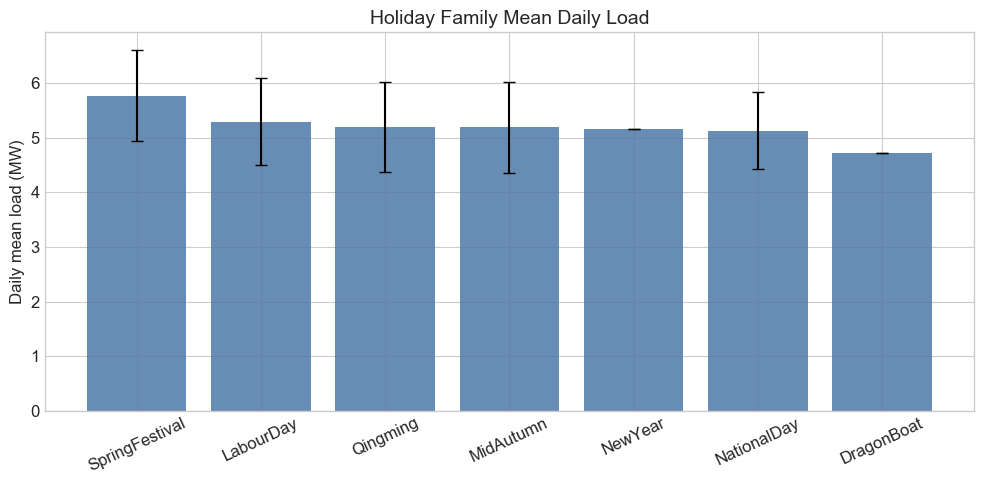

,count,mean,std
holiday_name,,,
SpringFestival,8,5.776,0.828
LabourDay,5,5.296,0.793
Qingming,3,5.199,0.820
MidAutumn,3,5.194,0.833
NewYear,1,5.172,NaN
NationalDay,7,5.133,0.704
DragonBoat,1,4.718,NaN


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
holiday_plot = holiday_family_stats.reset_index()
ax.bar(holiday_plot['holiday_name'], holiday_plot['mean'], yerr=holiday_plot['std'].fillna(0.0), color='#4e79a7', alpha=0.85, capsize=4)
ax.set_title('Holiday Family Mean Daily Load')
ax.set_ylabel('Daily mean load (MW)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

display(holiday_family_stats.round(3))


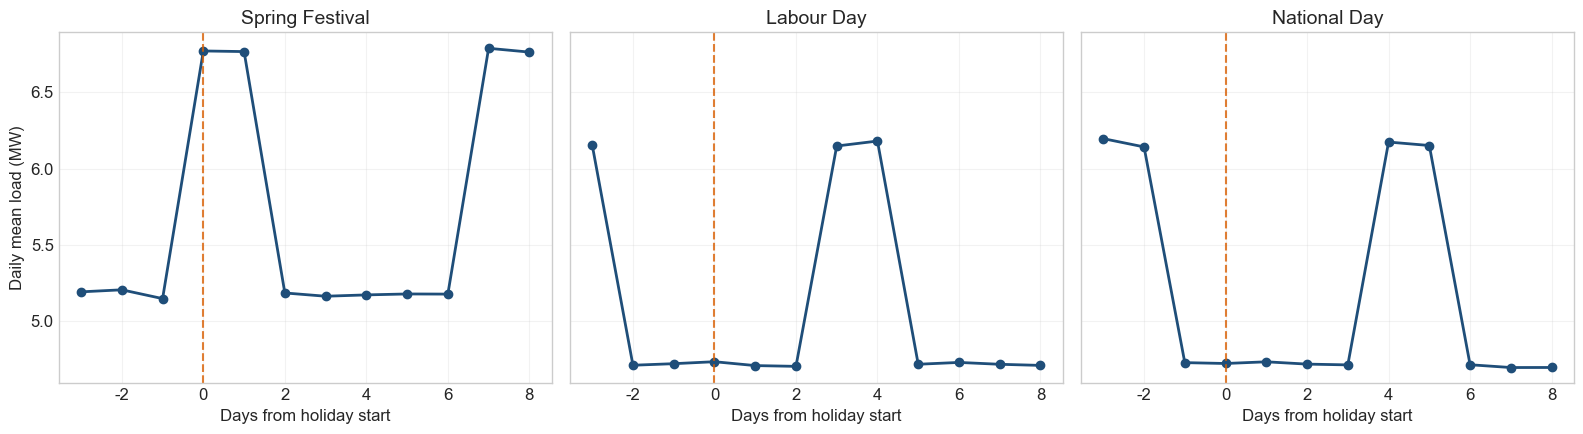

In [13]:
major_holidays = [('Spring Festival', '2024-02-10'), ('Labour Day', '2024-05-01'), ('National Day', '2024-10-01')]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (label, start_date) in zip(axes, major_holidays):
    center = pd.Timestamp(start_date)
    window = daily_df.loc[(daily_df.index >= center - pd.Timedelta(days=3)) & (daily_df.index <= center + pd.Timedelta(days=8)), 'mean_v']
    offsets = (window.index - center).days
    ax.plot(offsets, window.values, marker='o', linewidth=2, color='#1f4e79')
    ax.axvline(0, color='#d95f02', linestyle='--', alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel('Days from holiday start')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Daily mean load (MW)')
plt.tight_layout()
plt.show()


法定节假日不是同一种行为模式。

- 春节强度最高，更像长假返乡/出行模式。
- 五一和国庆前半段更接近低负荷工作日，后半段掺杂周末模式。
- 因此推荐的日历特征不是单个 `is_holiday`，而是：`holiday_family`、`is_makeup_workday`、节前/节后偏移天数。


---
## 6. External Tables: Signal or Just Time Encoding?


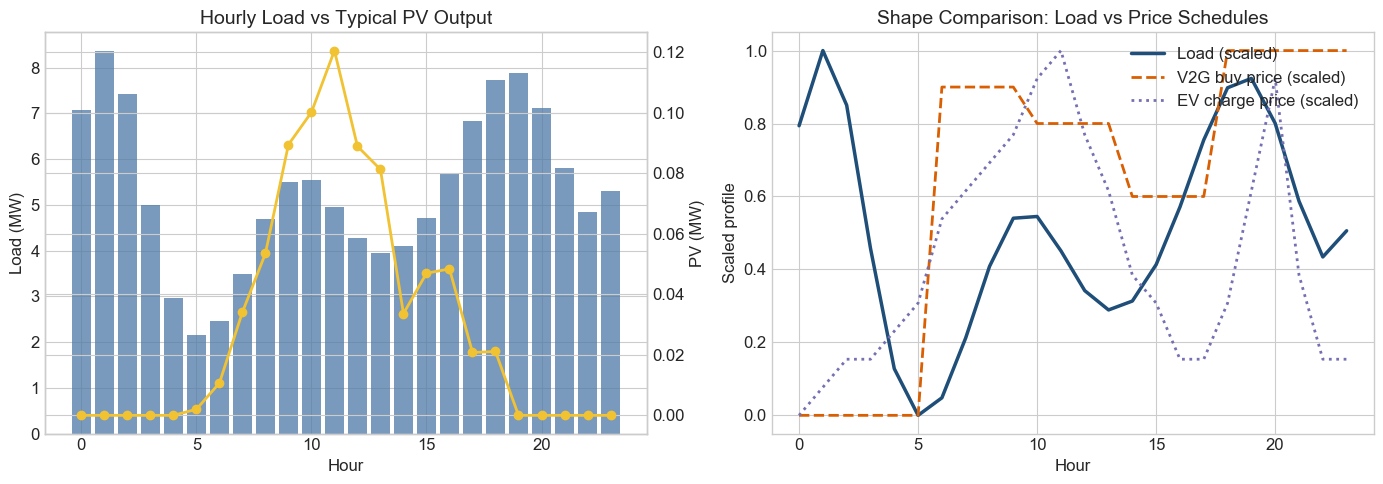

In [14]:
hourly_profile = train_df.groupby('hour').agg(
    load=('V', 'mean'),
    pv=('pv_mw', 'first'),
    v2g_buy=('v2g_buy_price', 'first'),
    ev_charge=('ev_charge_price', 'first')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_profile.index, hourly_profile['load'], color='#4e79a7', alpha=0.75, label='Avg load')
ax0_twin = axes[0].twinx()
ax0_twin.plot(hourly_profile.index, hourly_profile['pv'], color='#f1c232', marker='o', linewidth=2, label='PV output')
axes[0].set_title('Hourly Load vs Typical PV Output')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Load (MW)')
ax0_twin.set_ylabel('PV (MW)')

load_scaled = (hourly_profile['load'] - hourly_profile['load'].min()) / (hourly_profile['load'].max() - hourly_profile['load'].min())
v2g_scaled = (hourly_profile['v2g_buy'] - hourly_profile['v2g_buy'].min()) / (hourly_profile['v2g_buy'].max() - hourly_profile['v2g_buy'].min())
ev_scaled = (hourly_profile['ev_charge'] - hourly_profile['ev_charge'].min()) / (hourly_profile['ev_charge'].max() - hourly_profile['ev_charge'].min())
axes[1].plot(hourly_profile.index, load_scaled, linewidth=2.5, label='Load (scaled)', color='#1f4e79')
axes[1].plot(hourly_profile.index, v2g_scaled, linewidth=2, linestyle='--', label='V2G buy price (scaled)', color='#d95f02')
axes[1].plot(hourly_profile.index, ev_scaled, linewidth=2, linestyle=':', label='EV charge price (scaled)', color='#7570b3')
axes[1].set_title('Shape Comparison: Load vs Price Schedules')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Scaled profile')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


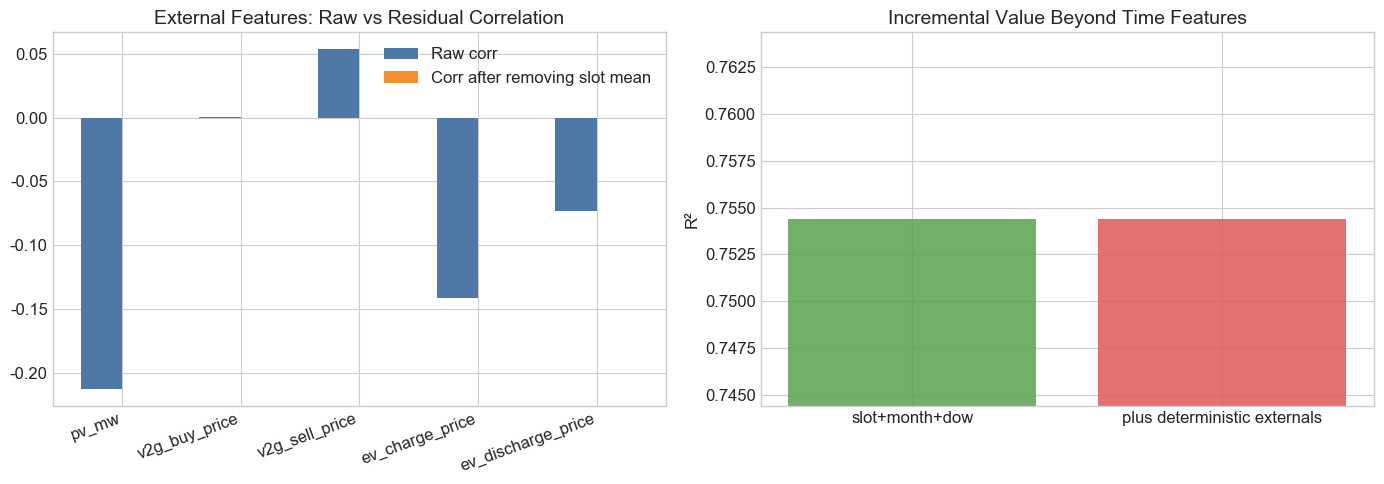

,feature,raw_corr,residual_corr
0,pv_mw,-0.213221,-2.098665e-17
1,v2g_buy_price,0.000326,-4.561184e-17
2,v2g_sell_price,0.053630,-3.671512e-17
3,ev_charge_price,-0.141669,-2.117913e-17
4,ev_discharge_price,-0.073216,-1.049843e-17


Baseline R²: 0.754368
Plus externals R²: 0.754368


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(external_eval_df))
width = 0.35
axes[0].bar(x - width / 2, external_eval_df['raw_corr'], width, label='Raw corr', color='#4e79a7')
axes[0].bar(x + width / 2, external_eval_df['residual_corr'], width, label='Corr after removing slot mean', color='#f28e2b')
axes[0].set_xticks(x)
axes[0].set_xticklabels(external_eval_df['feature'], rotation=20, ha='right')
axes[0].set_title('External Features: Raw vs Residual Correlation')
axes[0].legend()

axes[1].bar(['slot+month+dow', 'plus deterministic externals'], [summary['baseline_r2'], summary['plus_det_r2']], color=['#59a14f', '#e15759'], alpha=0.85)
axes[1].set_title('Incremental Value Beyond Time Features')
axes[1].set_ylabel('R²')
axes[1].set_ylim(min(summary['baseline_r2'], summary['plus_det_r2']) - 0.01, max(summary['baseline_r2'], summary['plus_det_r2']) + 0.01)

plt.tight_layout()
plt.show()

display(external_eval_df)
print(f"Baseline R²: {summary['baseline_r2']:.6f}")
print(f"Plus externals R²: {summary['plus_det_r2']:.6f}")


外部表有解释力，但统计新增信息没有想象中大。

- 控制 `slot + month + dow` 后，线性基线 `R² = 0.754368`。
- 再加入光伏/V2G/EV 价格后，`R² = 0.754368`。
- 基本无增益，说明这些外部表大部分只是时间段编码的另一种写法。
- 所以它们更适合作为**解释变量或交互变量**，而不是指望其单独带来巨大 leaderboard 提升。


---
## 7. Leakage Risk Audit


,field,evidence,can_use_for_true_future_forecast
0,AVGV,mean abs diff to true daily mean = 0.002547,No
1,MAXV,exact match rate = 1.000,No
2,MINV,exact match rate = 1.000,No
3,MAXT,datetime match rate = 1.000,No
4,MINT,datetime match rate = 1.000,No
5,S-family,not available at inference time on the leaderb...,No


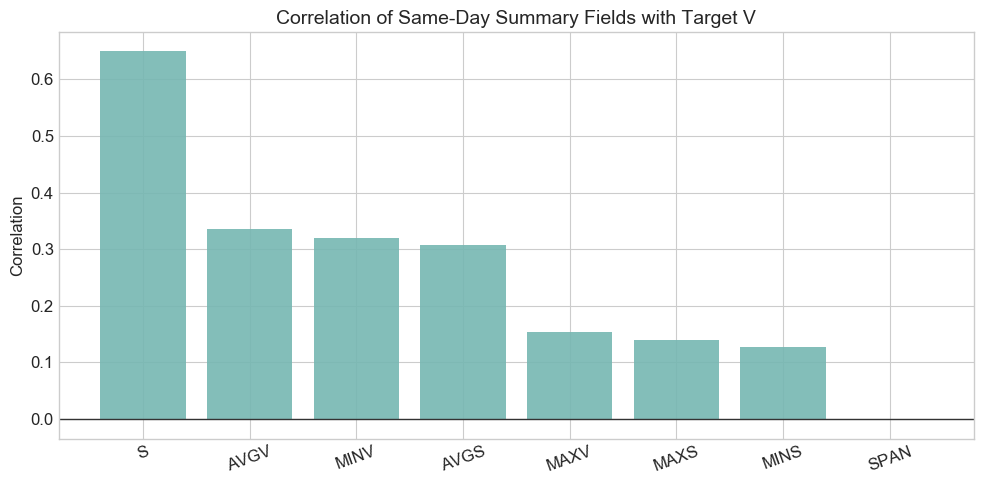

In [16]:
daily_first = train_df.groupby('date_ts').first()
actual_maxt = train_df.loc[train_df.groupby('date_ts')['V'].idxmax()].set_index('date_ts')['TIME']
actual_mint = train_df.loc[train_df.groupby('date_ts')['V'].idxmin()].set_index('date_ts')['TIME']

proof_table = pd.DataFrame({
    'field': ['AVGV', 'MAXV', 'MINV', 'MAXT', 'MINT', 'S-family'],
    'evidence': [
        f"mean abs diff to true daily mean = {summary['avgv_mean_abs_diff']:.6f}",
        f"exact match rate = {np.mean(np.isclose(daily_first['MAXV'].values, train_df.groupby('date_ts')['V'].max().values)):.3f}",
        f"exact match rate = {np.mean(np.isclose(daily_first['MINV'].values, train_df.groupby('date_ts')['V'].min().values)):.3f}",
        f"datetime match rate = {np.mean(pd.to_datetime(daily_first['MAXT']).values == actual_maxt.values):.3f}",
        f"datetime match rate = {np.mean(pd.to_datetime(daily_first['MINT']).values == actual_mint.values):.3f}",
        'not available at inference time on the leaderboard horizon'
    ],
    'can_use_for_true_future_forecast': ['No', 'No', 'No', 'No', 'No', 'No']
})

display(proof_table)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(leakage_corr.index, leakage_corr.values, color='#76b7b2', alpha=0.9)
ax.axhline(0.0, color='#333333', linewidth=1)
ax.set_title('Correlation of Same-Day Summary Fields with Target V')
ax.set_ylabel('Correlation')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


这一节是建模成败分水岭。

- `AVGV` 与当天真实均值的平均绝对差只有 **0.002547**。
- `MAXV / MAXT / MINV / MINT` 来自当天目标曲线本身。
- `S / AVGS / MAXS / MINS / SPAN` 在测试期同样不可直接获得。

如果不先把这些字段剔掉，线下验证会严重虚高。


---
## 8. EDA 结论与建模建议

### 8.1 比赛级结论总表

| 主题 | 结论 | 建模动作 |
| --- | --- | --- |
| 数据质量 | 训练集完整无缺失，但原始 CSV 首行是脏头 | 固定 `skiprows=1`，直接做时间序列特征 |
| 日内结构 | 主峰在 `01:30`，低谷在 `05:30`，晚间仍有次峰 | 强化 `slot`、`lag_96`、同槽位 rolling 特征 |
| 周末/调休 | 周末高 `30.53%`，调休工作日高 `28.50%` | 用 `weekday / weekend / holiday / makeup_workday` 四分类 |
| 节假日 | 不同节假日模式不同，单个 holiday dummy 太粗 | 加 `holiday_family` 和节前/节后偏移 |
| 外部表 | 光伏/价格大多是时间表映射，超出 `slot` 的信息很少 | 只作为补充或交互特征，不要高估 |
| 泄漏 | `AVGV / MAXV / MAXT / MINV / MINT` 明显泄漏，`S` 系列测试期不可用 | 训练时全部剔除 |

### 8.2 你的 4 个问题，最终判断

1. **日峰谷规律**
   - 成立，而且要更精确地表述为：工作日主峰长期锁在凌晨 `01:15-01:30`，周末/调休主峰会切到 `19:00-19:30`。
2. **周末 vs 工作日差异**
   - 非常强，但不能停留在二分类；中国调休会让简单 weekend dummy 失真。
3. **光伏是否削峰**
   - 从物理上可解释，但从统计上看增益有限；因为主峰主要发生在凌晨和傍晚，而不是光伏高输出时段。
4. **是否加节假日 dummy**
   - 建议加，但要升级成更细的日历体系；同时要注意 A 榜 2024-11-01 到 2024-12-31 这段时间法定节假日数是 **0**。

### 8.3 峰值时段迁移证据

- **Weekday**: `01:15` (87 days), `01:30` (82 days), `01:45` (23 days), `01:00` (7 days)
- **Weekend**: `19:30` (20 days), `19:00` (17 days), `19:15` (13 days), `18:45` (8 days)
- **Holiday**: `01:30` (10 days), `01:15` (7 days), `19:30` (5 days), `19:15` (2 days)
- **Make-up workday**: `18:45` (3 days), `19:30` (2 days), `19:15` (1 days), `19:45` (1 days)

### 8.4 建模路线建议

1. **先做严格时间验证的 tabular baseline**
   - 推荐 `LightGBM / CatBoost`
   - 特征以 `slot + dow + month + day_type + lag + rolling + holiday_family` 为核心
2. **显式加入交互项**
   - `day_type x slot`
   - `month x slot`
3. **做近期样本加权**
   - 因为 9-10 月更接近预测窗口，不应和 1-2 月等权
4. **外部表只做加分项**
   - 不要本末倒置，把主要精力放在时间结构与验证体系上
5. **严格避免泄漏列**
   - `AVGV / MAXV / MAXT / MINV / MINT / S / AVGS / MAXS / MINS / SPAN`

### 8.5 一句话结论

这道题最像 Kaggle 上典型的高频行为序列题：**真正决定上限的不是复杂模型名字，而是你是否把时间结构、日历切换、验证方式和泄漏边界先处理正确。**
